In [1]:
###### START ######

import pandas as pd
import statsmodels.api as sm

# Load the dataset
file_path = 'FinalProjectDataset.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset for review
data.head()

,disc_hire,gender,age,edu_cat,mariage,emp_fin,income_quartile,birth_region,health,disability,residence,disc_wage,disc_jobedu,disc_promotion,disc_resign,disc_edu,disc_home,disc_social
0,1.0,0,3,1,2,0,0,0,1,0,1,1,0,0,0,0,0,0
1,0.0,1,3,1,2,1,1,0,2,0,1,0,0,0,0,0,0,0
2,0.0,1,1,2,0,1,1,0,2,0,1,0,0,0,0,0,0,0
3,0.0,1,1,2,1,0,3,0,1,0,1,0,0,0,0,0,0,0
4,1.0,0,3,0,1,0,1,0,2,0,1,0,0,0,0,0,0,1


In [2]:
####### QUESTION 1  #######

from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

# Filter the dataset to include only participants with 'disc_hire' value as 0 or 1
filtered_data = data[data['disc_hire'].isin([0, 1])]

len(filtered_data)

# Define the response variable and explanatory variables
response = filtered_data['disc_hire']
explanatory = filtered_data.drop('disc_hire', axis=1)

# Fit a logistic regression model
logit_model = sm.Logit(response, sm.add_constant(explanatory))
result = logit_model.fit()

# Display the summary of the logistic regression model
result.summary()

Optimization terminated successfully.
         Current function value: 0.310260
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              disc_hire   No. Observations:                 3479
Model:                          Logit   Df Residuals:                     3461
Method:                           MLE   Df Model:                           17
Date:                Sat, 16 Dec 2023   Pseudo R-squ.:                  0.3751
Time:                        05:11:13   Log-Likelihood:                -1079.4
converged:                       True   LL-Null:                       -1727.2
Covariance Type:            nonrobust   LLR p-value:                3.918e-265
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.6120      0.273     -9.572      0.000      -3.147      -2.077
gender             -0.0521      0.120     -0.434      0.664      -0.287       0.183
age                 0.1300      0.062      2.084      0.037       0.008       0.252
edu_cat            -0.0691      0.092     -0.749      0.454      -0.250       0.112
mariage            -0.4246      0.134     -3.175      0.001      -0.687      -0.163
emp_fin             0.4897      0.133      3.679      0.000       0.229       0.751
income_quartile    -0.2322      0.057     -4.040      0.000      -0.345      -0.120
birth_region       -0.1042      0.149     -0.700      0.484      -0.396       0.187
health              0.1810      0.087      2.085      0.037       0.011       0.351
disability          0.2605      0.329      0.791      0.429      -0.385       0.905
residence           0.0396      0.012      3.182      0.001       0.015       0.064
disc_wage           3.2172      0.132     24.329      0.000       2.958       3.476
disc_jobedu         0.1118      0.114      0.983      0.325      -0.111       0.335
disc_promotion      0.1990      0.107      1.860      0.063      -0.011       0.409
disc_resign         0.1593      0.097      1.645      0.100      -0.031       0.349
disc_edu           -0.0154      0.142     -0.109      0.914      -0.294       0.263
disc_home          -0.1022      0.245     -0.416      0.677      -0.583       0.379
disc_social         1.1763      0.169      6.956      0.000       0.845       1.508
===================================================================================
"""

In [3]:
######## QUESTION 2 ########

import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Select the 12 specified variables
selected_columns = ['gender', 'age', 'edu_cat', 'emp_fin', 'income_quartile', 
                    'health', 'disability', 'disc_wage', 'disc_jobedu', 
                    'disc_promotion', 'disc_resign', 'disc_edu']
data_selected = data[selected_columns]
print(data_selected.head())

   gender  age  edu_cat  emp_fin  income_quartile  health  disability  \
0       0    3        1        0                0       1           0   
1       1    3        1        1                1       2           0   
2       1    1        2        1                1       2           0   
3       1    1        2        0                3       1           0   
4       0    3        0        0                1       2           0   

   disc_wage  disc_jobedu  disc_promotion  disc_resign  disc_edu  
0          1            0               0            0         0  
1          0            0               0            0         0  
2          0            0               0            0         0  
3          0            0               0            0         0  
4          0            0               0            0         0  


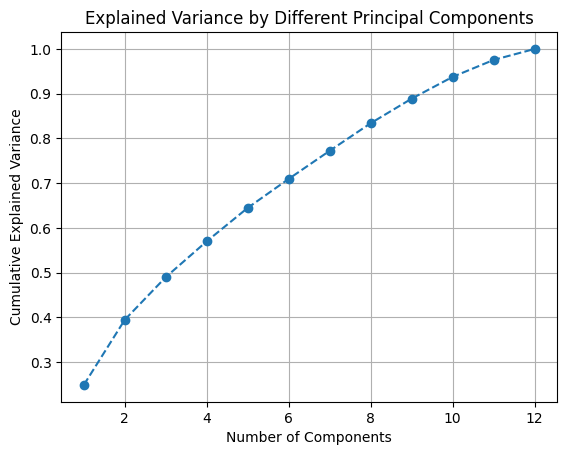

In [4]:
# Standardize the data
scaler = StandardScaler()
data_std = scaler.fit_transform(data_selected)

# Apply PCA
pca = PCA()
principalComponents = pca.fit_transform(data_std)

# Plotting the Cumulative Summation of the Explained Variance
plt.figure()
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Explained Variance by Different Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [5]:
# To decide the number of components, look at the plot and identify where the curve starts to plateau
# For instance, if you choose n_components:
n_components = 6 # choose based on the plot

# Re-run PCA with the chosen number of components
pca_final = PCA(n_components=n_components)
principalComponents_final = pca_final.fit_transform(data_std)

# The loadings of the components can be obtained as follows
loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)

# Convert loadings to a DataFrame for easier interpretation
loading_matrix = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(n_components)], 
                              index=data_selected.columns)

# Now you can interpret each component based on the loading scores
print(loading_matrix)


                      PC1       PC2       PC3       PC4       PC5       PC6
gender           0.167435  0.016164 -0.791322  0.043433  0.420158 -0.208187
age              0.322990 -0.596856  0.336981 -0.404556 -0.060399 -0.204470
edu_cat         -0.512316  0.596214  0.037254  0.090483  0.126472  0.204848
emp_fin          0.430839 -0.377448 -0.342500  0.225503 -0.220718  0.018825
income_quartile -0.443912  0.328414  0.136127 -0.407821  0.348345 -0.389241
health           0.272044 -0.494769 -0.041915 -0.221880  0.521121  0.237606
disability       0.143707 -0.201233  0.473983  0.686229  0.440559 -0.143829
disc_wage        0.581898  0.194007  0.095080 -0.017882 -0.024730 -0.405027
disc_jobedu      0.769294  0.312607  0.007479 -0.020416 -0.065548 -0.044124
disc_promotion   0.767150  0.349258 -0.004350  0.007794 -0.058350 -0.039403
disc_resign      0.559861  0.466811  0.109063 -0.014171  0.088114  0.019949
disc_edu         0.536045  0.158167  0.140313 -0.221308  0.221716  0.503064


In [6]:
# For each PC, list all the variables that have a loading score of more than 0.4 or less than -0.4

# PC1
def get_important_variables_positive(pc_number):
    pc = loading_matrix[f'PC{pc_number}']
    return pc[pc >= 0.4].index.tolist()

def get_important_variables_negative(pc_number):
    pc = loading_matrix[f'PC{pc_number}']
    return pc[pc <= -0.4].index.tolist()

for i in range(1, n_components + 1):
    print(f'PC{i}:')
    print('Positive:')
    print(get_important_variables_positive(i))
    print('Negative:')
    print(get_important_variables_negative(i))
    print()

PC1:
Positive:
['emp_fin', 'disc_wage', 'disc_jobedu', 'disc_promotion', 'disc_resign', 'disc_edu']
Negative:
['edu_cat', 'income_quartile']

PC2:
Positive:
['edu_cat', 'disc_resign']
Negative:
['age', 'health']

PC3:
Positive:
['disability']
Negative:
['gender']

PC4:
Positive:
['disability']
Negative:
['age', 'income_quartile']

PC5:
Positive:
['gender', 'health', 'disability']
Negative:
[]

PC6:
Positive:
['disc_edu']
Negative:
['disc_wage']



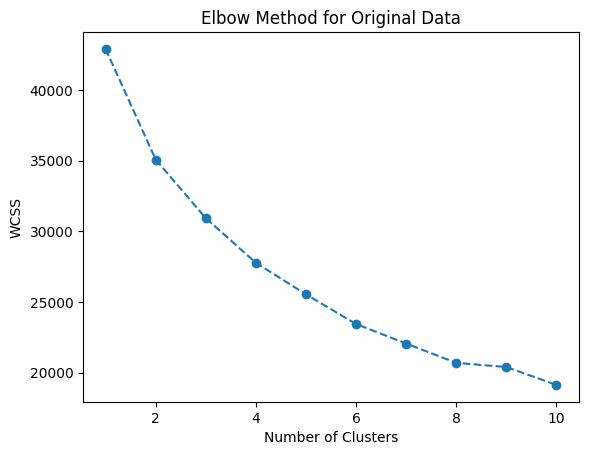

In [7]:
######## QUESTION 3 ########

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use the elbow method to find the optimal number of clusters for the original data
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42,  n_init=10)
    kmeans.fit(data_std)
    wcss.append(kmeans.inertia_)

# Plot the WCSS to visualize the elbow
plt.figure()
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Original Data')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

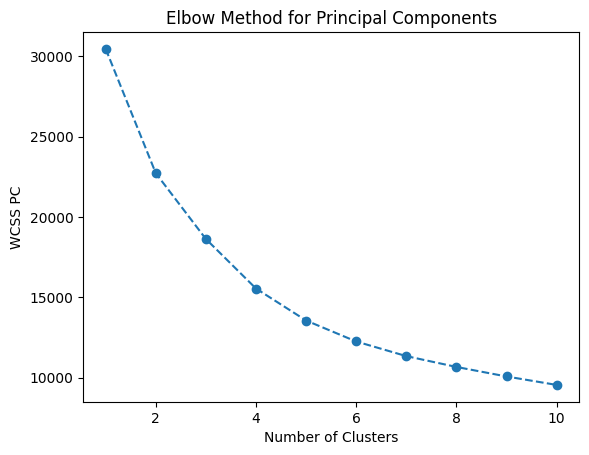

In [8]:

# Repeat the elbow method for the principal component scores
wcss_pc = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42,  n_init=10)
    kmeans.fit(principalComponents_final)
    wcss_pc.append(kmeans.inertia_)

# Plot the WCSS for the principal components
plt.figure()
plt.plot(range(1, 11), wcss_pc, marker='o', linestyle='--')
plt.title('Elbow Method for Principal Components')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS PC')
plt.show()



[0.3886352817651522, 0.18694685183094326, 0.19260753315260604, 0.2030767989136083, 0.18141674832258664, 0.18452338676141566, 0.18999973811689994, 0.16120908048093185, 0.19435808701557794]


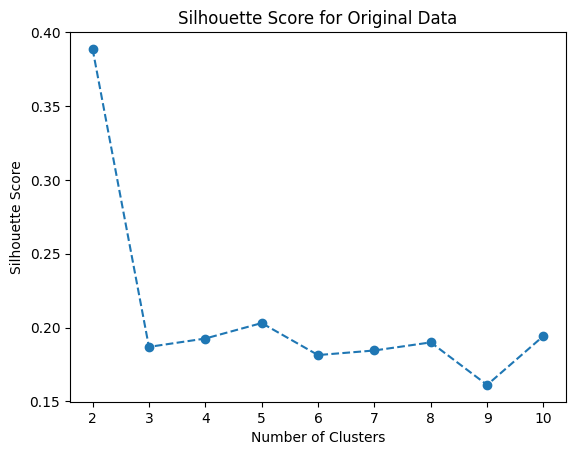

In [9]:
# Calculate the silhouette score for the original data
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42,  n_init=10)
    kmeans.fit(data_std)
    silhouette_scores.append(silhouette_score(data_std, kmeans.labels_))

print(silhouette_scores)

# Plot the silhouette scores
plt.figure()
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Original Data')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()


[0.43271092001702816, 0.26038375242252376, 0.2678054519739871, 0.2583508571849802, 0.2668585999617924, 0.2471834680812384, 0.23929089926436536, 0.244002548646122, 0.2289522427004001]


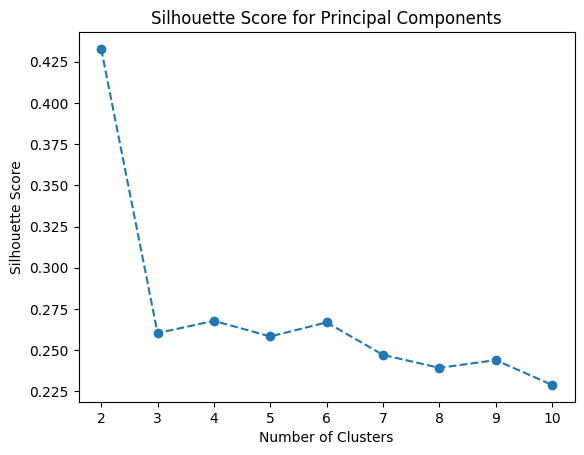

In [10]:
# Calculate the silhouette score for the principal components
silhouette_scores_pc = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42,  n_init=10)
    kmeans.fit(principalComponents_final)
    silhouette_scores_pc.append(silhouette_score(principalComponents_final, kmeans.labels_))

print(silhouette_scores_pc)

# Plot the silhouette scores
plt.figure()
plt.plot(range(2, 11), silhouette_scores_pc, marker='o', linestyle='--')
plt.title('Silhouette Score for Principal Components')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [11]:
# Choose the number of clusters (n_clusters) based on the elbow plots
n_clusters = 4# determined from the elbow plot

# Perform K-means clustering with the chosen number of clusters on original data
kmeans_original = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
clusters_original = kmeans_original.fit_predict(data_std)

# Perform K-means clustering with the chosen number of clusters on principal components
kmeans_pc = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42,  n_init=10)
clusters_pc = kmeans_pc.fit_predict(principalComponents_final)

# Describe the clusters by examining the centroids
centroids_original = kmeans_original.cluster_centers_
centroids_pc = kmeans_pc.cluster_centers_

# Convert centroids to a DataFrame for easier interpretation
centroids_original_df = pd.DataFrame(scaler.inverse_transform(centroids_original), columns=data_selected.columns)
centroids_pc_df = pd.DataFrame(centroids_pc, columns=[f'PC{i+1}' for i in range(n_components)])

# Now you can describe each cluster by looking at the values of the centroids
print("Centroids for Original Data:")
print(centroids_original_df)
print("\nCentroids for Principal Components:")
print(centroids_pc_df)


Centroids for Original Data:
     gender       age   edu_cat   emp_fin  income_quartile    health  \
0  0.350000  1.482828  1.581818  0.057576         2.175253  1.201010   
1  0.437963  2.797222  0.463889  0.464815         1.239815  1.687963   
2  0.542453  2.193396  0.740566  0.466981         1.167453  1.523585   
3  0.163043  2.641304  0.630435  0.369565         1.108696  1.750000   

     disability  disc_wage  disc_jobedu  disc_promotion  disc_resign  disc_edu  
0  1.040834e-17   0.079798     0.024747        0.101010     0.153030  0.018182  
1  1.387779e-17   0.174074     0.041667        0.100926     0.045370  0.043519  
2  1.040834e-17   0.639151     1.610849        1.754717     1.183962  0.580189  
3  1.000000e+00   0.326087     0.347826        0.456522     0.402174  0.206522  

Centroids for Principal Components:
        PC1       PC2       PC3       PC4       PC5       PC6
0  0.278335 -1.396666 -0.263279 -0.219982 -0.263442 -0.069367
1  3.550545  1.275823 -0.072147 -0.250900 -0

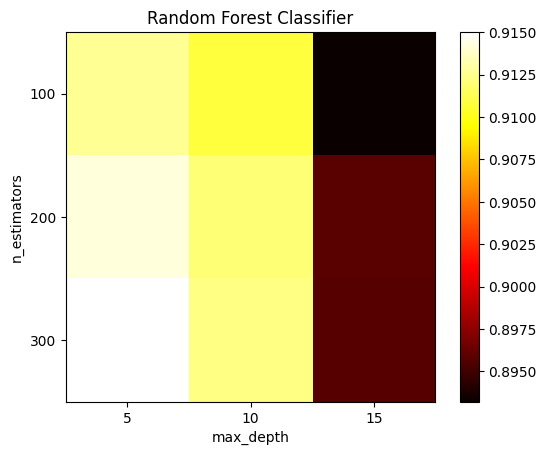

In [12]:
######## QUESTION 4 ########

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve

# Assuming `data` is your full dataset
# Filter out the participants with 'NA' for 'disc_hire' and prepare the data for modeling
data_model = data[data['disc_hire'].notna()]
X = data_model.drop(['disc_hire'], axis=1)
y = data_model['disc_hire'].astype('int')  # Ensure the target is integer

# Splitting data into training and test sets for cross-validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a Random Forest Classifier and a grid for cross-validation
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, 15]}

# Conduct Grid Search to find the optimal parameters for Random Forest
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='roc_auc')
grid_search_rf.fit(X_train, y_train)
rf_best_params = grid_search_rf.best_params_
rf_best_score = grid_search_rf.best_score_

# Drawing graph for n_estimators and max_depth and see which one produces the best score
n_estimators = [100, 200, 300]
max_depth = [5, 10, 15]
scores = []
for n in n_estimators:
    for d in max_depth:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_test)[:, 1]
        score = roc_auc_score(y_test, y_pred)
        scores.append(score)

scores = np.array(scores).reshape(len(n_estimators), len(max_depth))
plt.figure()
plt.imshow(scores, cmap='hot', interpolation='nearest')
plt.xticks(np.arange(len(max_depth)), max_depth)
plt.yticks(np.arange(len(n_estimators)), n_estimators)
plt.xlabel('max_depth')
plt.ylabel('n_estimators')
plt.colorbar()
plt.title('Random Forest Classifier')
plt.show()





In [13]:

# Define a Penalized Logistic Regression with Lasso penalty
logreg_cv = LogisticRegressionCV(cv=5, penalty='l1', solver='liblinear', scoring='roc_auc', random_state=42, max_iter=1000)
logreg_cv.fit(X_train, y_train)
logreg_best_score = logreg_cv.scores_[1].mean(axis=0).max()

# Comparing the AUC scores to select the best model
best_model = grid_search_rf.best_estimator_ if rf_best_score > logreg_best_score else logreg_cv

# Print the best model's parameters
print(best_model)

# Print both model's AUC score on the test set
print(f'Random Forest AUC: {roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])}')
print(f'Logistic Regression AUC: {roc_auc_score(y_test, logreg_cv.predict_proba(X_test)[:, 1])}')

RandomForestClassifier(max_depth=5, n_estimators=300, random_state=42)
Random Forest AUC: 0.9150162709106626
Logistic Regression AUC: 0.896342858595617


In [14]:
# Predicting the probabilities on the test set using the best model
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Calculating the ROC curve and determining the optimal threshold
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

optimal_threshold

0.18278975364991587

In [15]:

# Predicting on the data of the 97 participants who responded 'NA'
NA_data = data[data['disc_hire'].isna()]
NA_pred_prob = best_model.predict_proba(NA_data.drop(['disc_hire'], axis=1))[:, 1]
NA_pred = (NA_pred_prob >= optimal_threshold).astype(int)

# Analyzing the predicted distribution between males and females
NA_data['predicted_disc_hire'] = NA_pred
predicted_distribution = NA_data.groupby('gender')['predicted_disc_hire'].value_counts(normalize=True).unstack()

# This gives you the proportion of predicted 'Yes' responses for hiring discrimination for each gender
print(predicted_distribution)

predicted_disc_hire         0         1
gender                                 
0                    0.515625  0.484375
1                    0.090909  0.909091


C:\Users\Munim Hasan Wasi\AppData\Local\Temp\ipykernel_28120\2738980739.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NA_data['predicted_disc_hire'] = NA_pred


In [16]:
######## QUESTION 5 ########

import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.multicomp import MultiComparison

# Assuming `data` contains all participants and `NA_data` contains the 97 participants with 'NA' responses
# Add the predictions to the NA_data
NA_data['health_group'] = 'NA_' + NA_data['predicted_disc_hire'].map({0: 'No', 1: 'Yes'})


# Drop the 'NA' responses from the original data
data_without_na = data[data['disc_hire'].notna()]

# Create the health group for the rest of the data
data_without_na['health_group'] = data_without_na['disc_hire'].map({0: 'No', 1: 'Yes'})

# Combine both datasets
combined_data = pd.concat([data_without_na[['health', 'health_group']], NA_data[['health', 'health_group']]])



C:\Users\Munim Hasan Wasi\AppData\Local\Temp\ipykernel_28120\1836012498.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NA_data['health_group'] = 'NA_' + NA_data['predicted_disc_hire'].map({0: 'No', 1: 'Yes'})
C:\Users\Munim Hasan Wasi\AppData\Local\Temp\ipykernel_28120\1836012498.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_without_na['health_group'] = data_without_na['disc_hire'].map({0: 'No', 1: 'Yes'})


In [17]:
# Conduct an overall ANOVA test
f_value, p_value = stats.f_oneway(combined_data[combined_data['health_group'] == 'No']['health'],
                                   combined_data[combined_data['health_group'] == 'Yes']['health'],
                                   combined_data[combined_data['health_group'] == 'NA_No']['health'],
                                   combined_data[combined_data['health_group'] == 'NA_Yes']['health'])

print(f'ANOVA test results: F-value = {f_value}, p-value = {p_value}')

# If the overall p_value is significant, perform pairwise comparisons
if p_value < 0.05:
    mc = MultiComparison(combined_data['health'], combined_data['health_group'])
    tukey_result = mc.tukeyhsd(alpha=0.05)
    print(tukey_result.summary())
else:
    print("No significant differences were found among the four groups.")


ANOVA test results: F-value = 9.768620169293053, p-value = 2.0423449383710158e-06
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 NA_No NA_Yes   0.0751 0.9526 -0.2915 0.4417  False
 NA_No     No  -0.0482 0.9744 -0.3408 0.2443  False
 NA_No    Yes   0.1052 0.8013  -0.193 0.4034  False
NA_Yes     No  -0.1234 0.4964 -0.3491 0.1024  False
NA_Yes    Yes   0.0301 0.9874  -0.203 0.2631  False
    No    Yes   0.1534    0.0  0.0791 0.2278   True
---------------------------------------------------


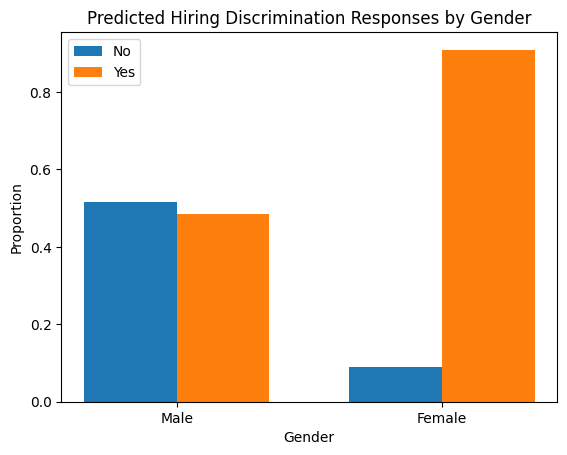

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data for predicted 'disc_hire' responses by gender
gender_categories = ['Male', 'Female']
no_responses = [0.515625, 0.090909]  # Proportion of 'No' responses
yes_responses = [0.484375, 0.909091]  # Proportion of 'Yes' responses

# Number of categories
n_categories = len(gender_categories)

# Creating a bar chart
fig, ax = plt.subplots()

# Setting the positions and width for the bars
bar_width = 0.35
index = np.arange(n_categories)

# Plotting 'No' and 'Yes' responses
bar1 = ax.bar(index, no_responses, bar_width, label='No')
bar2 = ax.bar(index + bar_width, yes_responses, bar_width, label='Yes')

# Adding labels, title and axes ticks
ax.set_xlabel('Gender')
ax.set_ylabel('Proportion')
ax.set_title('Predicted Hiring Discrimination Responses by Gender')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(gender_categories)
ax.legend()

# Displaying the graph
plt.show()


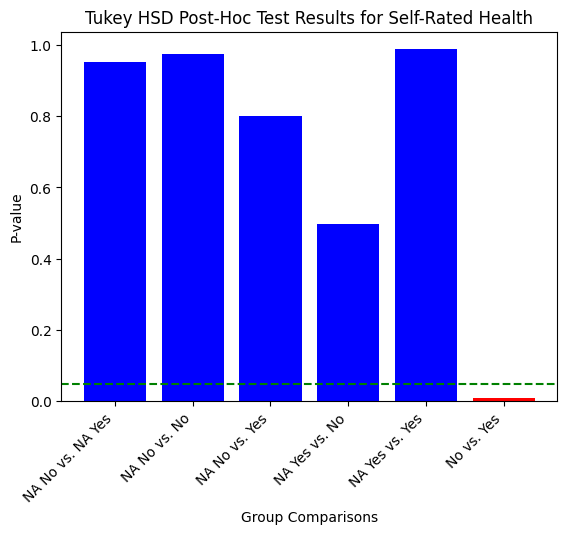

In [12]:
# Tukey HSD post-hoc test results data
groups = ['NA No vs. NA Yes', 'NA No vs. No', 'NA No vs. Yes', 
          'NA Yes vs. No', 'NA Yes vs. Yes', 'No vs. Yes']
p_values = [0.9526, 0.9744, 0.8013, 0.4964, 0.9874, 0.01]

# Creating a bar chart to visualize the p-values
fig, ax = plt.subplots()

# Bar plot
ax.bar(groups, p_values, color=['blue', 'blue', 'blue', 'blue', 'blue', 'red'])

# Adding labels and title
ax.set_xlabel('Group Comparisons')
ax.set_ylabel('P-value')
ax.set_title('Tukey HSD Post-Hoc Test Results for Self-Rated Health')
# ax.set_yscale('log')  # Log scale due to wide range of p-values
ax.axhline(y=0.05, color='green', linestyle='--')  # Significance level line

# Rotating x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Displaying the graph
plt.show()


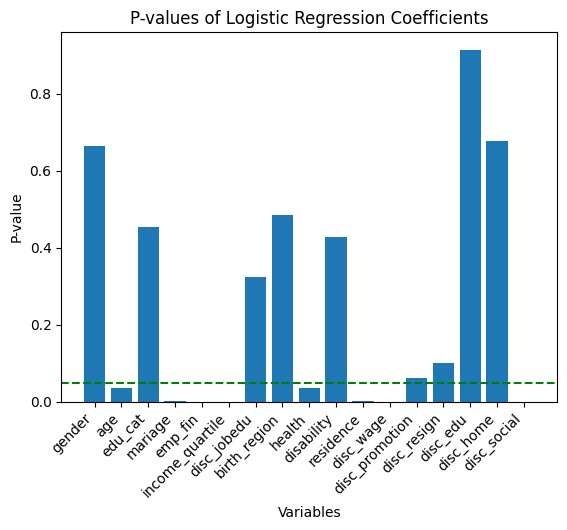

In [20]:
# Data for logistic regression coefficients and p-values
variables = ['gender', 'age', 'edu_cat', 'mariage', 'emp_fin', 'income_quartile',
             'disc_jobedu', 'birth_region', 'health', 'disability', 'residence', 
             'disc_wage', 'disc_promotion', 'disc_resign', 'disc_edu', 
             'disc_home', 'disc_social']
coefficients = [-0.0521, 0.1300, -0.0691, -0.4246, 0.4897, -0.2322, 
                0.1118, -0.1042, 0.1810, 0.2605, 0.0396, 3.2172, 
                0.1990, 0.1593, -0.0154, -0.1022, 1.1763]
p_values = [0.664, 0.037, 0.454, 0.001, 0.000, 0.000, 
            0.325, 0.484, 0.037, 0.429, 0.001, 0.000, 
            0.063, 0.100, 0.914, 0.677, 0.000]




# Creating a bar chart to visualize the p-values
fig, ax = plt.subplots()


# Bar plot

ax.bar(variables, p_values)

# Adding labels and title
ax.set_xlabel('Variables')
ax.set_ylabel('P-value')
ax.set_title('P-values of Logistic Regression Coefficients')
ax.axhline(y=0.05, color='green', linestyle='--')  # Significance level line



# Rotating x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Displaying the graph
plt.show()


In [15]:
# list variables which has p-value less than 0.05
significant_variables = [variables[i] for i in range(len(variables)) if p_values[i] < 0.05]
print(significant_variables)


['age', 'mariage', 'emp_fin', 'income_quartile', 'health', 'residence', 'disc_wage', 'disc_social']
